# Importing

## Import Library

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/deeplumiere/automobile-market-analytics-dataset/automobile_dataset.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('/kaggle/input/datasets/deeplumiere/automobile-market-analytics-dataset/automobile_dataset.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Make,Model,Year,Fuel_Type,Transmission,Engine_Size,Mileage,Horsepower,Torque,Owners,Accident_History,Service_History,Color,Body_Type,Drivetrain,Fuel_Efficiency,Location,Selling_Price
0,Mercedes-Benz,GLE,2024,Petrol,Automatic,2.3,100,186.0,196.0,1,0.0,NaN,Silver,SUV,AWD,30.0,IL,64140
1,Hyundai,Tucson,2008,Petrol,Automatic,2.3,387035,189.0,190.0,4,0.0,NaN,Blue,SUV,FWD,35.0,FL,500
2,Volkswagen,Golf,2021,Hybrid,NaN,1.9,46054,158.0,153.0,1,0.0,Partial Service,Gray,Hatchback,AWD,43.0,NY,16429
3,Chevrolet,Tahoe,2005,Petrol,NaN,2.2,141302,169.0,165.0,5,1.0,No Service,Blue,SUV,AWD,NaN,FL,2199
4,Toyota,Camry,2022,Petrol,Automatic,1.9,32813,149.0,141.0,1,0.0,Full Service,Brown,Sedan,FWD,38.0,CA,21792


## last Five row

In [4]:
df.tail()

,Make,Model,Year,Fuel_Type,Transmission,Engine_Size,Mileage,Horsepower,Torque,Owners,Accident_History,Service_History,Color,Body_Type,Drivetrain,Fuel_Efficiency,Location,Selling_Price
5495,Volkswagen,Tiguan,2022,Petrol,Automatic,NaN,29506,161.0,NaN,1,0.0,Partial Service,Black,SUV,AWD,33.0,GA,20333
5496,Nissan,Pathfinder,2006,Petrol,Automatic,3.1,287332,243.0,227.0,5,1.0,No Service,Gray,SUV,AWD,NaN,NY,500
5497,BMW,X3,2013,Petrol,Automatic,2.2,95961,171.0,152.0,2,1.0,No Service,Blue,SUV,AWD,32.0,MI,9882
5498,Volkswagen,Golf,2020,Hybrid,Automatic,1.5,56643,135.0,125.0,2,1.0,No Service,White,Hatchback,FWD,57.0,NY,10474
5499,Chevrolet,Tahoe,2011,Petrol,Automatic,2.1,169929,168.0,158.0,3,1.0,NaN,Gray,SUV,AWD,NaN,MI,6193


## Shape of our dataset

In [5]:
df.shape

(5500, 18)

## List out all columns

In [6]:
df.columns

Index(['Make', 'Model', 'Year', 'Fuel_Type', 'Transmission', 'Engine_Size',
       'Mileage', 'Horsepower', 'Torque', 'Owners', 'Accident_History',
       'Service_History', 'Color', 'Body_Type', 'Drivetrain',
       'Fuel_Efficiency', 'Location', 'Selling_Price'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Make                 object
Model                object
Year                  int64
Fuel_Type            object
Transmission         object
Engine_Size         float64
Mileage               int64
Horsepower          float64
Torque              float64
Owners                int64
Accident_History    float64
Service_History      object
Color                object
Body_Type            object
Drivetrain           object
Fuel_Efficiency     float64
Location             object
Selling_Price         int64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Make              5500 non-null   object 
 1   Model             5500 non-null   object 
 2   Year              5500 non-null   int64  
 3   Fuel_Type         5500 non-null   object 
 4   Transmission      4673 non-null   object 
 5   Engine_Size       4656 non-null   float64
 6   Mileage           5500 non-null   int64  
 7   Horsepower        4700 non-null   float64
 8   Torque            4701 non-null   float64
 9   Owners            5500 non-null   int64  
 10  Accident_History  4688 non-null   float64
 11  Service_History   4645 non-null   object 
 12  Color             4697 non-null   object 
 13  Body_Type         5500 non-null   object 
 14  Drivetrain        5500 non-null   object 
 15  Fuel_Efficiency   4706 non-null   float64
 16  Location          4718 non-null   object 


## Check Null Value

In [9]:
df.isnull().sum()

Make                  0
Model                 0
Year                  0
Fuel_Type             0
Transmission        827
Engine_Size         844
Mileage               0
Horsepower          800
Torque              799
Owners                0
Accident_History    812
Service_History     855
Color               803
Body_Type             0
Drivetrain            0
Fuel_Efficiency     794
Location            782
Selling_Price         0
dtype: int64

## Handle all missing values

In [10]:
num_cols = [
    'Engine_Size',
    'Horsepower',
    'Torque',
    'Accident_History',
    'Fuel_Efficiency'
]

cat_cols = [
    'Transmission',
    'Service_History',
    'Color',
    'Location'
]

## Fill numerical columns with median

In [11]:
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

## Fill categorical columns with mode

In [12]:
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

## Check remaining missing values

In [13]:
print(df.isnull().sum())

Make                0
Model               0
Year                0
Fuel_Type           0
Transmission        0
Engine_Size         0
Mileage             0
Horsepower          0
Torque              0
Owners              0
Accident_History    0
Service_History     0
Color               0
Body_Type           0
Drivetrain          0
Fuel_Efficiency     0
Location            0
Selling_Price       0
dtype: int64


## Check Dupicate Value

In [14]:
df.duplicated().sum()

np.int64(0)

## Summary

In [15]:
df.describe()

,Year,Engine_Size,Mileage,Horsepower,Torque,Owners,Accident_History,Fuel_Efficiency,Selling_Price
count,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000
mean,2014.494000,2.442855,114529.481636,196.602182,187.414545,2.464000,0.347818,33.865091,12319.873636
std,5.789745,0.776668,91858.943421,51.621268,52.499359,1.280022,0.476321,13.974959,12658.478862
min,2005.000000,0.000000,100.000000,97.000000,77.000000,1.000000,0.000000,10.000000,500.000000
25%,2009.000000,2.100000,39112.000000,165.000000,156.000000,1.000000,0.000000,28.000000,1304.750000
50%,2014.000000,2.400000,96926.500000,187.000000,178.000000,2.000000,0.000000,32.000000,8586.000000
75%,2020.000000,2.800000,172757.500000,223.000000,212.000000,3.000000,1.000000,36.000000,19097.500000
max,2024.000000,5.700000,536731.000000,434.000000,443.000000,5.000000,1.000000,141.000000,86692.000000


# EDA

In [16]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

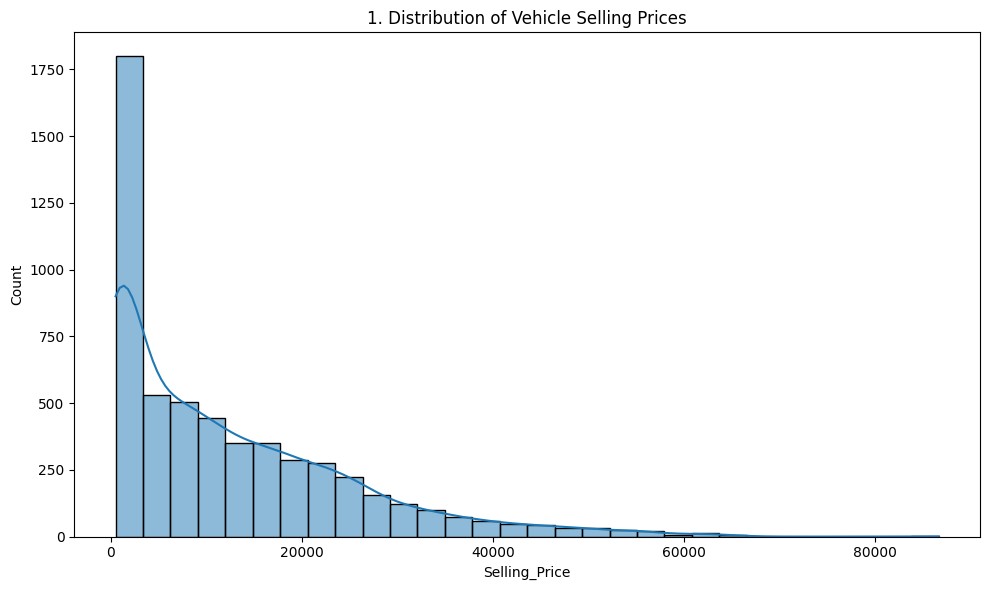

In [17]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Selling_Price'], bins=30, kde=True)
plt.title(f'{plot_no}. Distribution of Vehicle Selling Prices')
show_fig()
plot_no += 1

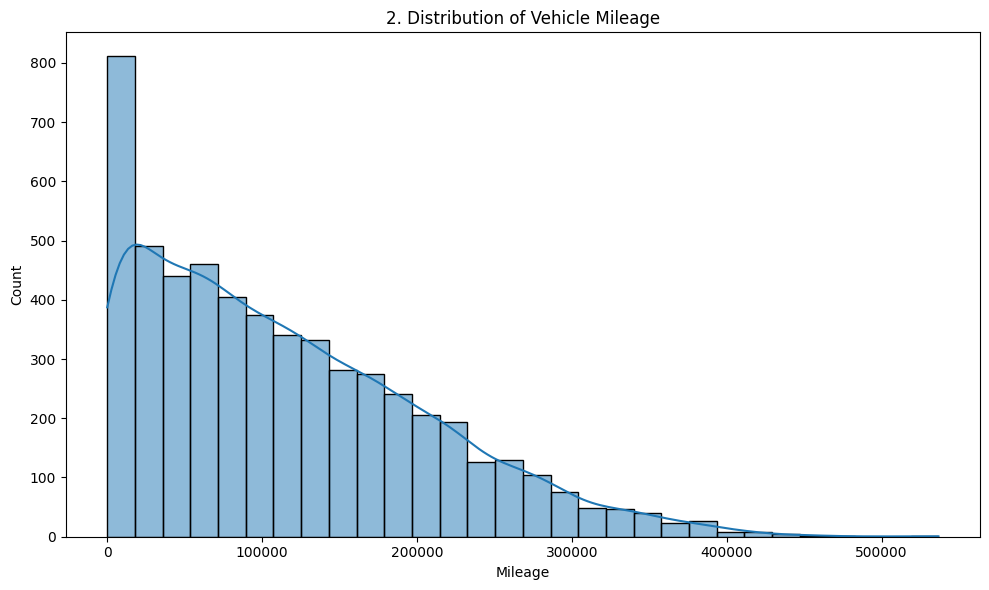

In [18]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Mileage'], bins=30, kde=True)
plt.title(f'{plot_no}. Distribution of Vehicle Mileage')
show_fig()
plot_no += 1

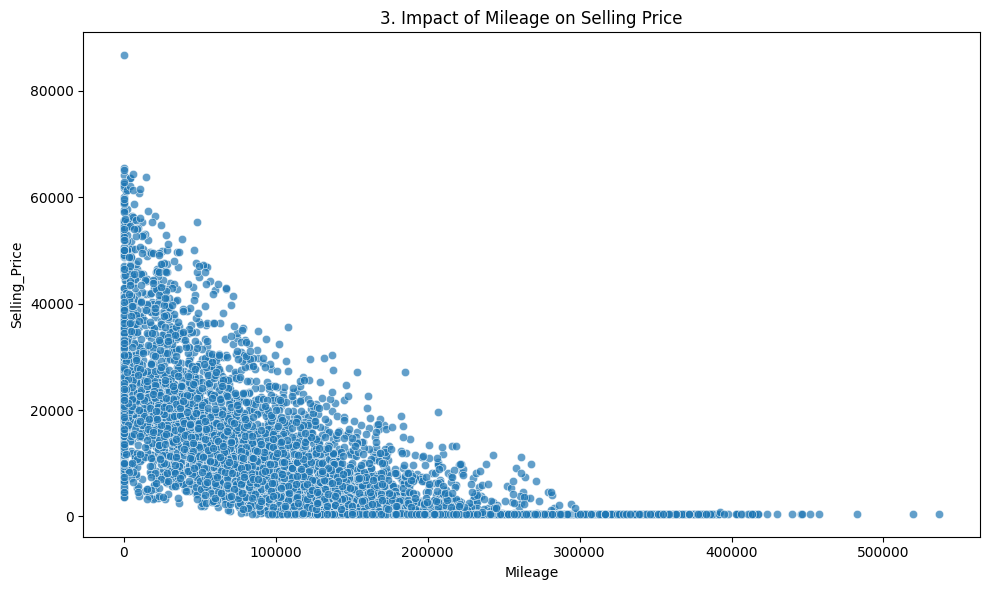

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Mileage', y='Selling_Price', alpha=0.7)
plt.title(f'{plot_no}. Impact of Mileage on Selling Price')
show_fig()
plot_no += 1

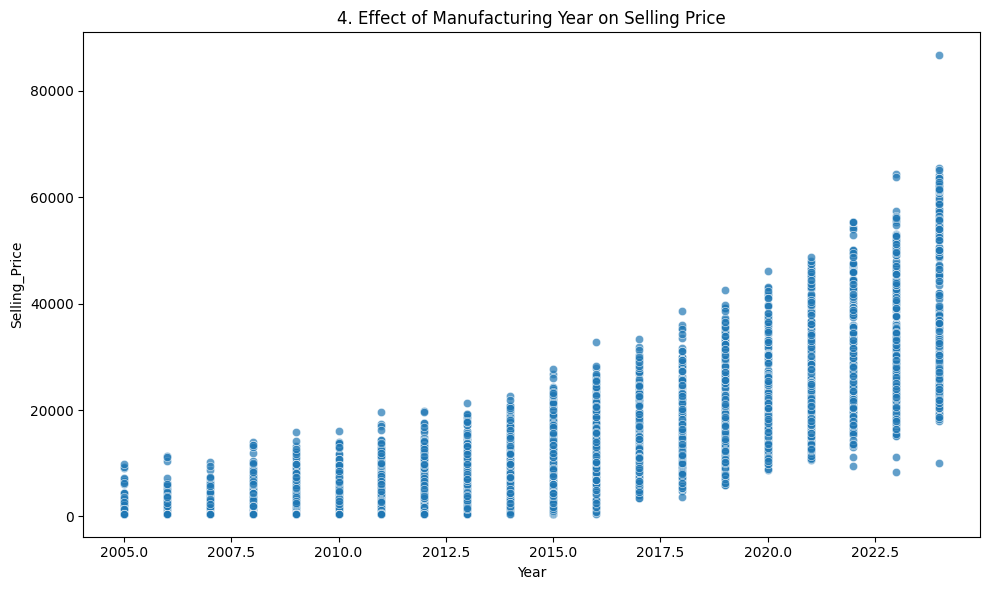

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Year', y='Selling_Price', alpha=0.7)
plt.title(f'{plot_no}. Effect of Manufacturing Year on Selling Price')
show_fig()
plot_no += 1

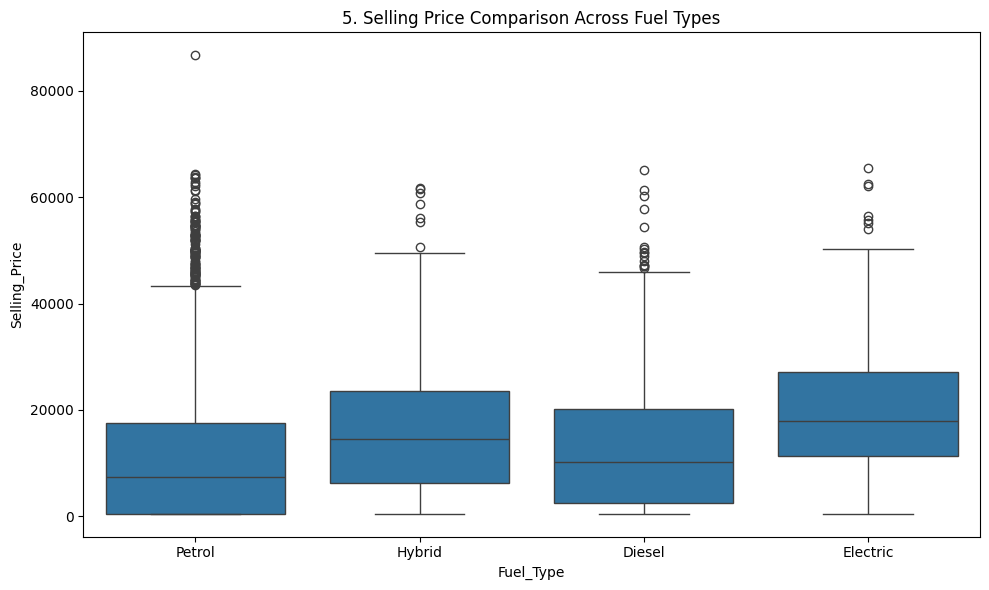

In [21]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Fuel_Type', y='Selling_Price')
plt.title(f'{plot_no}. Selling Price Comparison Across Fuel Types')
show_fig()
plot_no += 1

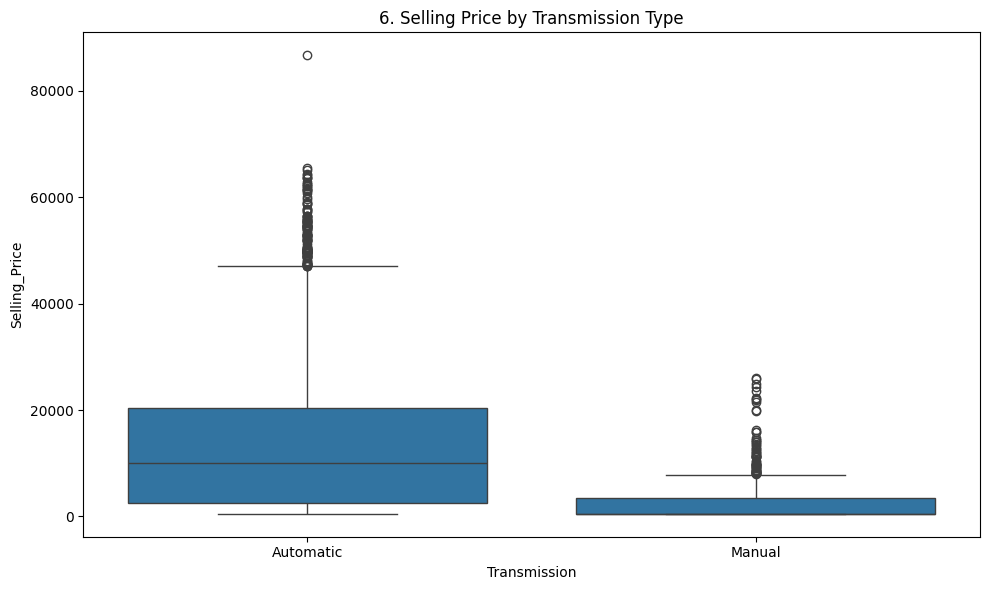

In [22]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Transmission', y='Selling_Price')
plt.title(f'{plot_no}. Selling Price by Transmission Type')
show_fig()
plot_no += 1

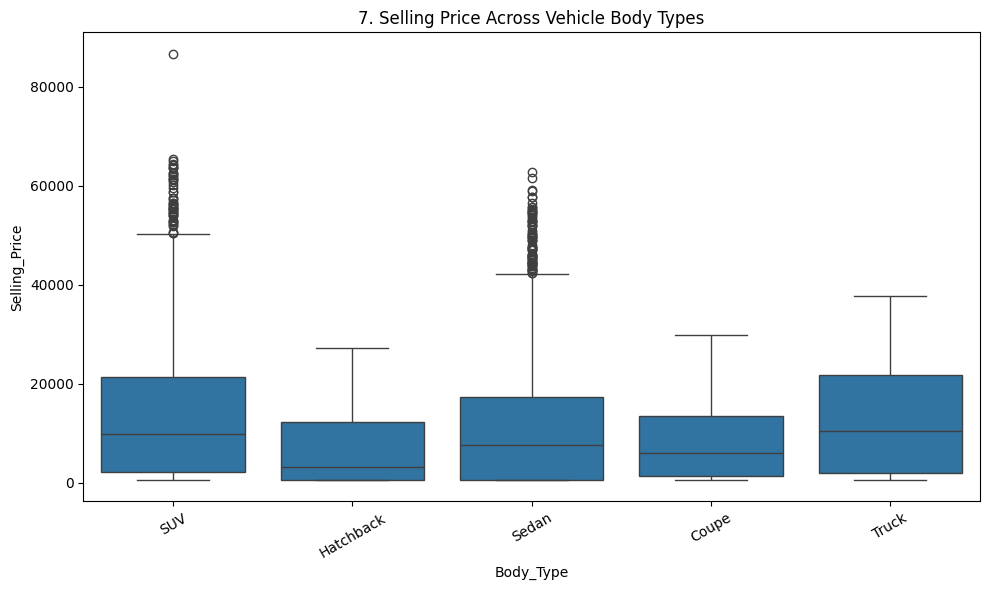

In [23]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Body_Type', y='Selling_Price')
plt.xticks(rotation=30)
plt.title(f'{plot_no}. Selling Price Across Vehicle Body Types')
show_fig()
plot_no += 1

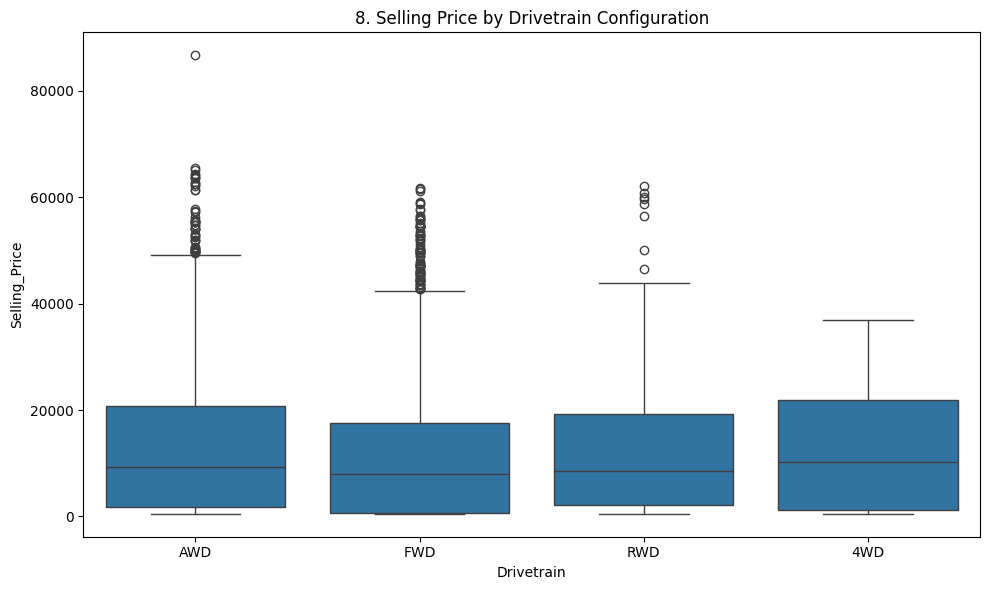

In [24]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Drivetrain', y='Selling_Price')
plt.title(f'{plot_no}. Selling Price by Drivetrain Configuration')
show_fig()
plot_no += 1

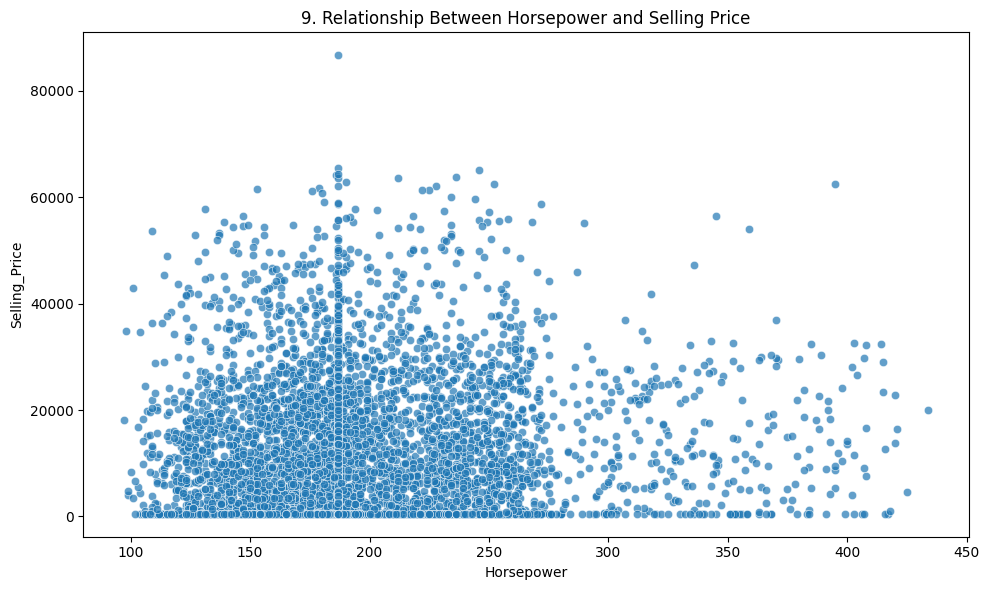

In [25]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Horsepower', y='Selling_Price', alpha=0.7)
plt.title(f'{plot_no}. Relationship Between Horsepower and Selling Price')
show_fig()
plot_no += 1

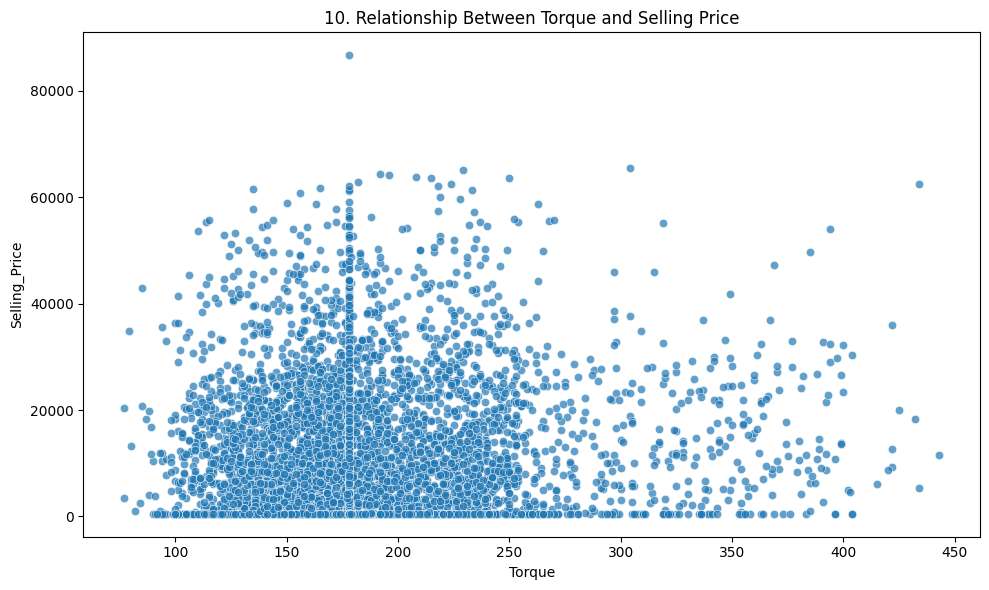

In [26]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Torque', y='Selling_Price', alpha=0.7)
plt.title(f'{plot_no}. Relationship Between Torque and Selling Price')
show_fig()
plot_no += 1

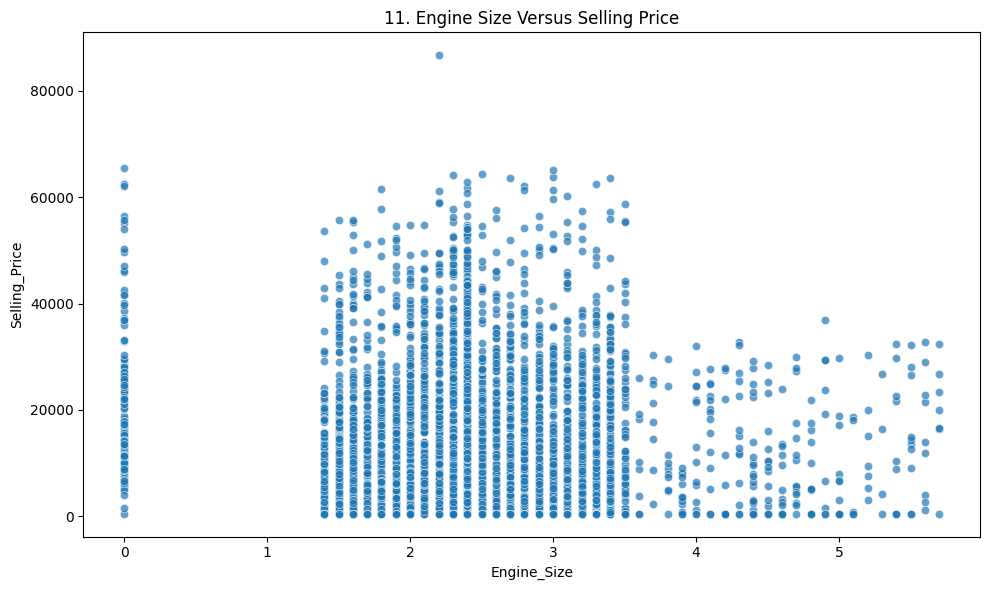

In [27]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Engine_Size', y='Selling_Price', alpha=0.7)
plt.title(f'{plot_no}. Engine Size Versus Selling Price')
show_fig()
plot_no += 1

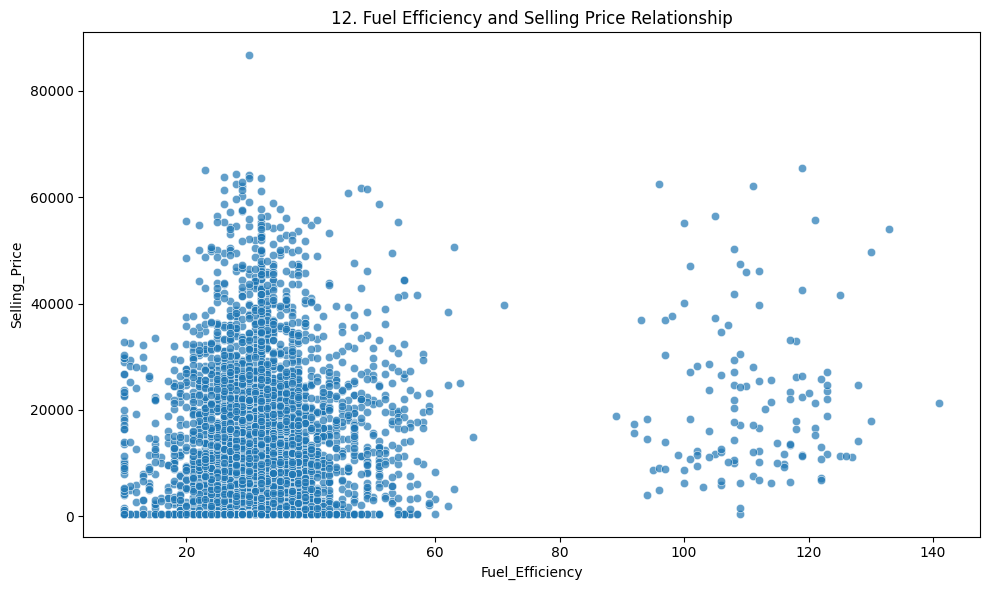

In [28]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Fuel_Efficiency', y='Selling_Price', alpha=0.7)
plt.title(f'{plot_no}. Fuel Efficiency and Selling Price Relationship')
show_fig()
plot_no += 1

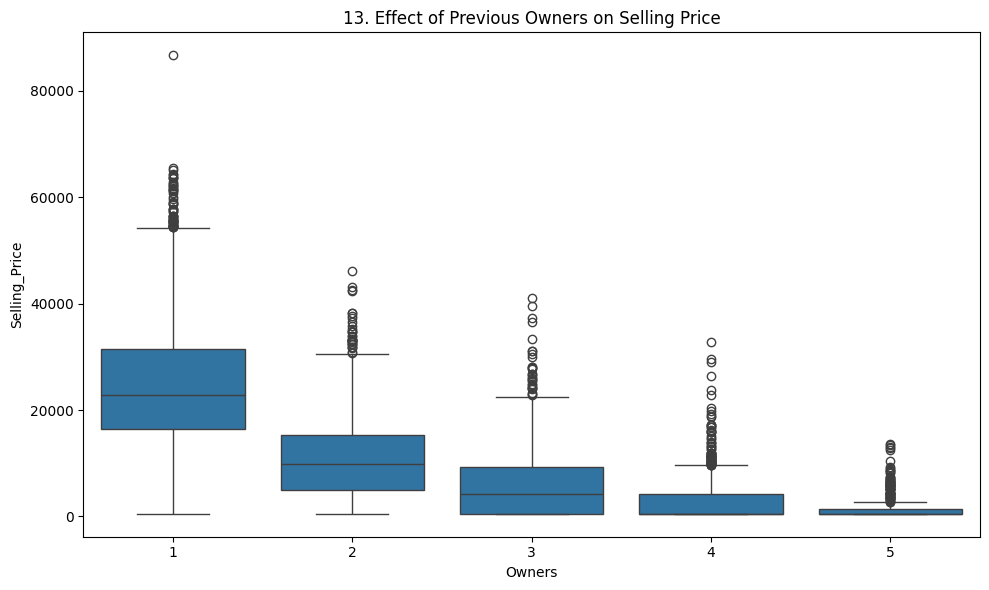

In [29]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Owners', y='Selling_Price')
plt.title(f'{plot_no}. Effect of Previous Owners on Selling Price')
show_fig()
plot_no += 1

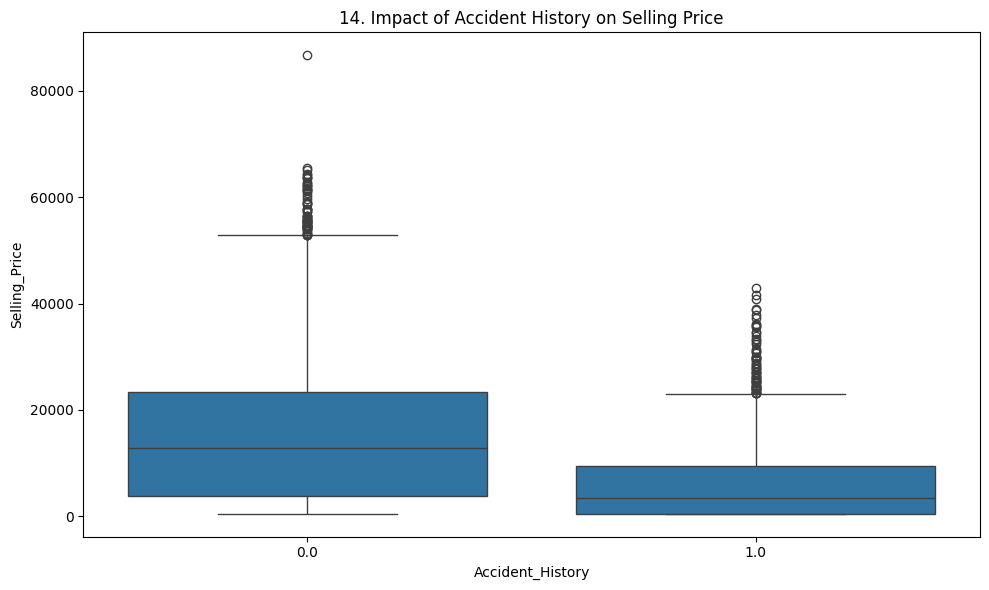

In [30]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Accident_History', y='Selling_Price')
plt.title(f'{plot_no}. Impact of Accident History on Selling Price')
show_fig()
plot_no += 1

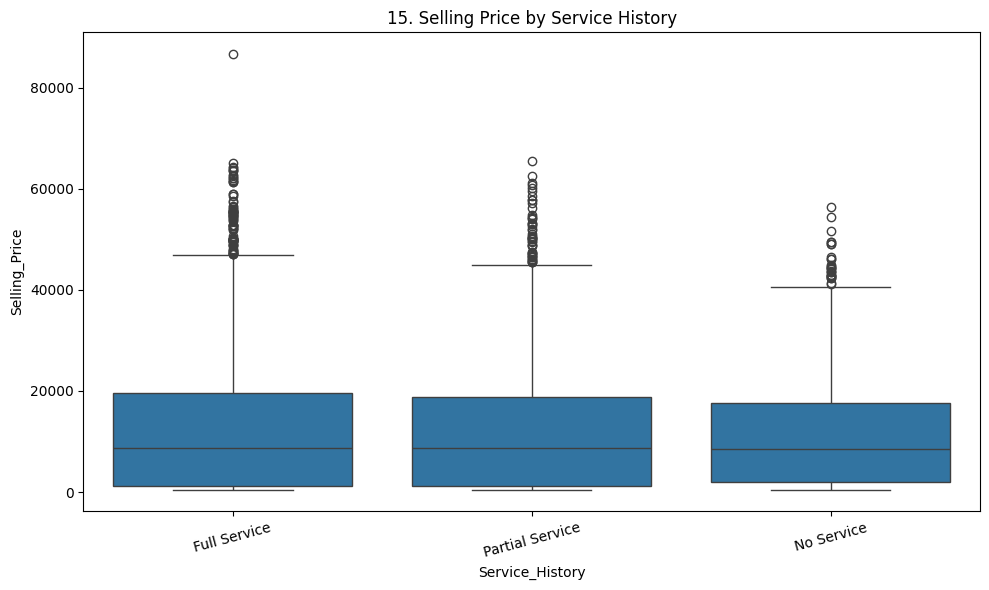

In [31]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Service_History', y='Selling_Price')
plt.xticks(rotation=15)
plt.title(f'{plot_no}. Selling Price by Service History')
show_fig()
plot_no += 1

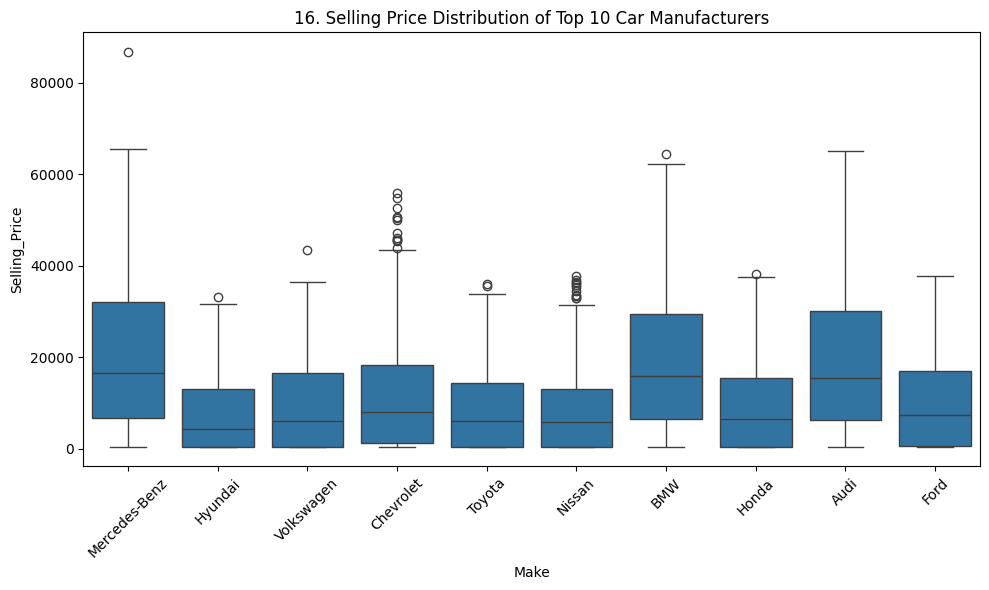

In [32]:
fig = plt.figure(figsize=(10,6))
top_make = df['Make'].value_counts().head(10).index
sns.boxplot(data=df[df['Make'].isin(top_make)], x='Make', y='Selling_Price')
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Selling Price Distribution of Top 10 Car Manufacturers')
show_fig()
plot_no += 1

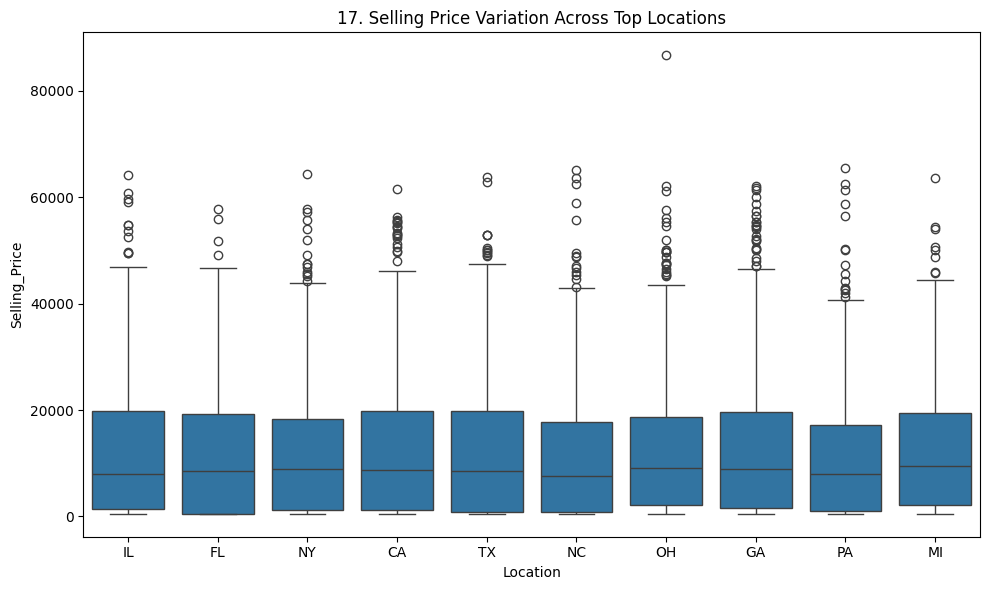

In [33]:
fig = plt.figure(figsize=(10,6))
top_location = df['Location'].value_counts().head(10).index
sns.boxplot(data=df[df['Location'].isin(top_location)], x='Location', y='Selling_Price')
plt.title(f'{plot_no}. Selling Price Variation Across Top Locations')
show_fig()
plot_no += 1

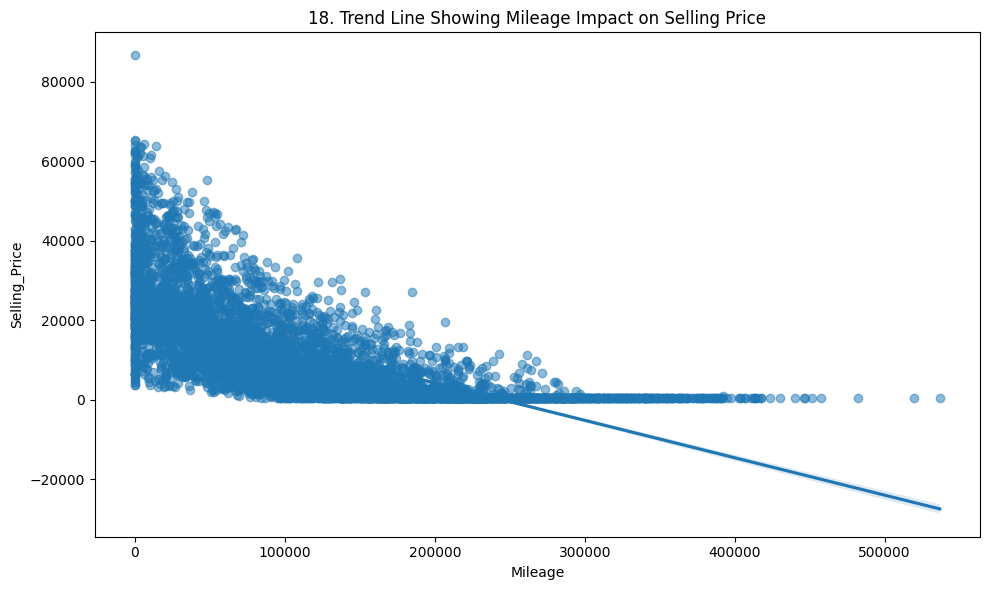

In [34]:
fig = plt.figure(figsize=(10,6))
sns.regplot(data=df, x='Mileage', y='Selling_Price', scatter_kws={'alpha':0.5})
plt.title(f'{plot_no}. Trend Line Showing Mileage Impact on Selling Price')
show_fig()
plot_no += 1

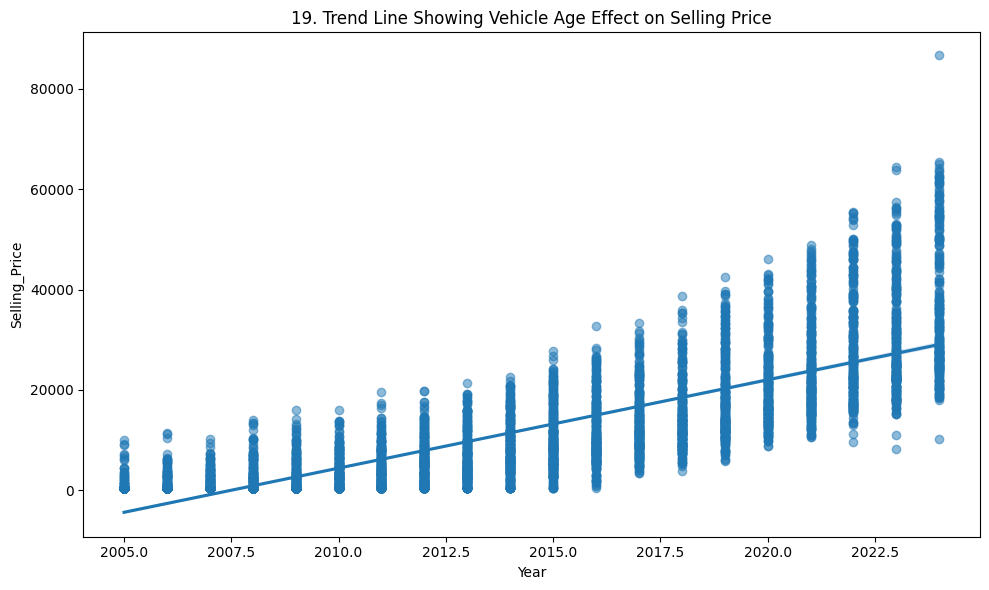

In [35]:
fig = plt.figure(figsize=(10,6))
sns.regplot(data=df, x='Year', y='Selling_Price', scatter_kws={'alpha':0.5})
plt.title(f'{plot_no}. Trend Line Showing Vehicle Age Effect on Selling Price')
show_fig()
plot_no += 1

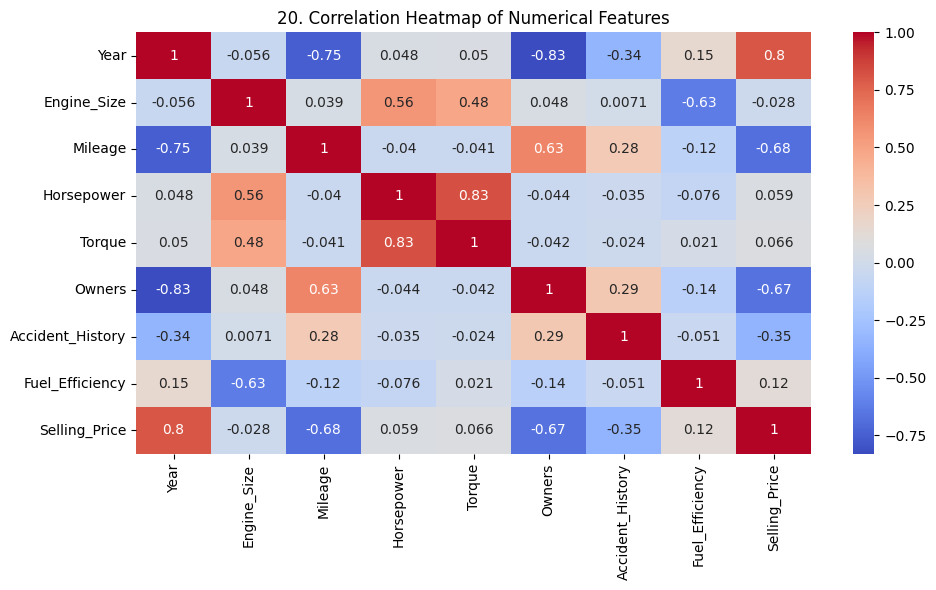

In [36]:
fig = plt.figure(figsize=(10,6))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Features')
show_fig()
plot_no += 1

# Model Training

## Separate features and target

In [37]:
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

## Define numerical and categorical columns

In [38]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

## Create preprocessing pipeline

In [39]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

## Split the dataset

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Create complete machine learning pipeline

In [41]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    ))
])

## Train the model

In [42]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Year', 'Engine_Size', 'Mileage', 'Horsepower', 'Torque', 'Owners',
       'Accident_History', 'Fuel_Efficiency'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Make', 'Model', 'Fuel_Type', 'Transmission', 'Service_History',
       'Color', 'Body_Type', 'Drivetrain', 'Location'],
      dtype='object'))])),
                ('regressor',
                 GradientBoostingRegressor(learning_rate=0.05, max_depth=4,
                                           n_estimators=300,
                                           random_state=42))])

## Predict on test data

In [43]:
y_pred = model.predict(X_test)

## Calculate evaluation metrics

In [44]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

## Print model performance

In [45]:
print(f'R² Score (Accuracy): {r2:.4f}')
print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')

R² Score (Accuracy): 0.9810
MAE: 1148.53
RMSE: 1728.79


## Plot Actual vs Predicted values

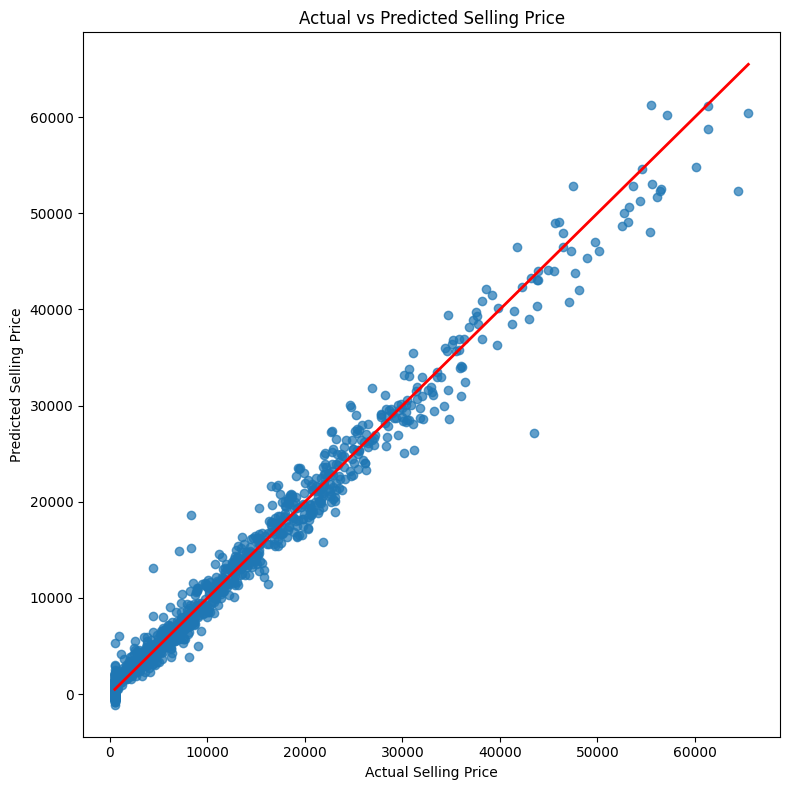

In [46]:
plt.figure(figsize=(8,8))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red',
         linewidth=2)
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual vs Predicted Selling Price')
plt.tight_layout()
plt.show()